# Historical AQI Interpolation — LOSO Cross-Validation

**Purpose:** Evaluate all five interpolation methods on the historical station dataset  
(`cleaned_aqi_mumbai_imputed.csv`, Jul–Dec 2025, 27 CPCB/MPCB stations across Mumbai).

**Method:** Leave-One-Station-Out Cross-Validation (LOSO CV)  
For each station *i* in turn: hold it out, fit the interpolator on the remaining 26 stations,  
predict AQI at station *i*'s location, record the error. Repeat for every station and aggregate.

**Slices evaluated:**
1. **Overall** — mean AQI per station across all 6 months
2. **Per month** — Jul / Aug / Sep / Oct / Nov / Dec separately
3. **Time of day** — Night / Morning rush / Midday / Evening rush
4. **Weekday vs Weekend**

**Metrics:**
| Metric | Meaning | Better when |
|--------|---------|-------------|
| RMSE | Root mean squared error — penalises large errors | ↓ lower |
| MAE | Mean absolute error — average AQI unit deviation | ↓ lower |
| Bias | Mean signed error (+= over-predicts) | → 0 |
| R² | Variance explained | ↑ closer to 1 |

---
> **Self-contained:** All interpolation logic is defined inline — no import from `modules/`.

## 0. Imports & Configuration

In [4]:
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.interpolate import RBFInterpolator
from scipy.spatial import cKDTree

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
# Adjust if running from a different working directory
CSV_PATH = Path("data/cleaned_aqi_mumbai_imputed.csv")
if not CSV_PATH.exists():
    CSV_PATH = Path("cleaned_aqi_mumbai_imputed.csv")   # fallback: same dir

# ── CRS ────────────────────────────────────────────────────────────────────────
GEO_CRS  = "EPSG:4326"       # WGS84 lat/lon
PROJ_CRS = "EPSG:32643"      # UTM Zone 43N — metric CRS for Mumbai

# ── CPCB AQI palette ───────────────────────────────────────────────────────────
AQI_PALETTE = {
    "Good":         "#00c400",
    "Satisfactory": "#92d14f",
    "Moderate":     "#e0c800",
    "Poor":         "#ff7e00",
    "Very Poor":    "#e00000",
    "Severe":       "#7e0023",
}

MONTH_NAMES = {7:"Jul", 8:"Aug", 9:"Sep", 10:"Oct", 11:"Nov", 12:"Dec"}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f9fa",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11,
})
print("✅ Imports complete")

✅ Imports complete


## 1. Load & Explore the Historical Dataset

In [7]:
df = pd.read_csv("C:\\Users\\keenu\\Downloads\\files_copy_latest\\files_copy_latest\\cleaned_aqi_mumbai_imputed.csv", parse_dates=["datetime"])
df["month"]      = df["datetime"].dt.month
df["hour"]       = df["datetime"].dt.hour
df["is_weekend"] = (df["datetime"].dt.dayofweek >= 5).astype(int)

# Short station name (drop ' - AGENCY-ID' suffix for readability)
df["stn_short"] = df["station_name"].str.split(",").str[0]

print(f"Rows: {len(df):,}")
print(f"Stations: {df['station_name'].nunique()}")
print(f"Date range: {df['datetime'].min().date()} → {df['datetime'].max().date()}")
print(f"AQI missing: {df['aqi'].isna().sum():,} / {len(df):,} ({df['aqi'].isna().mean():.1%})")
df.head(3)

Rows: 100,464
Stations: 27
Date range: 2025-07-01 → 2025-12-31
AQI missing: 464 / 100,464 (0.5%)


,datetime,station_id,station_name,lat,lon,pm25,pm10,no2,co,so2,...,temp,rh,ws,wd,aqi,aqi_category,month,hour,is_weekend,stn_short
0,2025-07-01 00:00:00,6927.0,"Colaba, Mumbai - MPCB-3379614",18.91,72.82,17.400000,54.6000,24.680000,0.600000,8.38,...,33.317175,99.41,NaN,NaN,56.0,Satisfactory,7,0,0,Colaba
1,2025-07-01 01:00:00,6927.0,"Colaba, Mumbai - MPCB-3379614",18.91,72.82,18.218333,54.6000,24.613333,0.597500,8.38,...,33.250566,99.41,NaN,NaN,56.0,Satisfactory,7,1,0,Colaba
2,2025-07-01 02:00:00,6927.0,"Colaba, Mumbai - MPCB-3379614",18.91,72.82,19.465556,36.6025,24.615000,0.598333,8.38,...,31.736839,99.41,NaN,NaN,37.0,Good,7,2,0,Colaba


In [8]:
# ── Station catalogue ──────────────────────────────────────────────────────────
stations_cat = (
    df.groupby(["station_name", "stn_short", "lat", "lon"])
    .agg(
        aqi_mean=("aqi", "mean"),
        aqi_std=("aqi", "std"),
        aqi_min=("aqi", "min"),
        aqi_max=("aqi", "max"),
        n_obs=("aqi", "count"),
    )
    .reset_index()
    .sort_values("aqi_mean", ascending=False)
)
print(f"\n{'Station':<45} {'Mean AQI':>9} {'Std':>7} {'Min':>5} {'Max':>5} {'N obs':>7}")
print("-" * 78)
for _, r in stations_cat.iterrows():
    print(f"{r['stn_short']:<45} {r['aqi_mean']:>9.1f} {r['aqi_std']:>7.1f} "
          f"{r['aqi_min']:>5.0f} {r['aqi_max']:>5.0f} {r['n_obs']:>7,}")


Station                                        Mean AQI     Std   Min   Max   N obs
------------------------------------------------------------------------------
Powai                                             171.8   133.0    21   500   3,558
Shivaji Nagar                                     119.0    94.9    22   366   4,047
Deonar                                            115.4    65.2    31   317   4,187
Chhatrapati Shivaji Intl. Airport (T2)            111.4    79.4    39   310   3,570
Bandra Kurla Complex                              110.5    80.8     0   345   3,071
Vile Parle West                                   109.7    82.5    20   393   2,951
Sion                                              104.2    92.1    21   347   3,498
Kurla                                              99.0    29.4    48   243   1,865
Mulund West                                        98.8    65.0    23   314   3,573
Siddharth Nagar-Worli                              97.8    59.1    21   327   4,

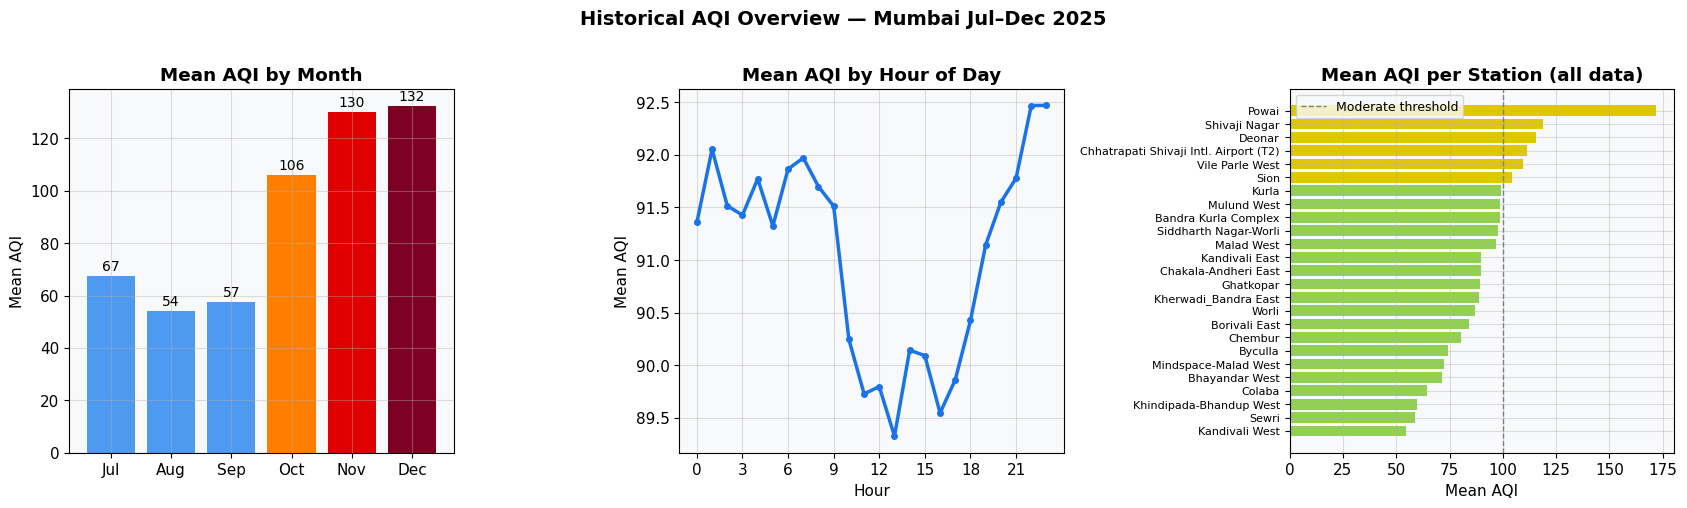

Saved → 01_overview.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Monthly mean AQI
monthly = df.groupby("month")["aqi"].mean()
axes[0].bar([MONTH_NAMES[m] for m in monthly.index], monthly.values,
            color=["#4e9af1","#4e9af1","#4e9af1","#ff7e00","#e00000","#7e0023"])
axes[0].set_title("Mean AQI by Month", fontweight="bold")
axes[0].set_ylabel("Mean AQI")
for i, (m, v) in enumerate(monthly.items()):
    axes[0].text(i, v+2, f"{v:.0f}", ha="center", fontsize=10)

# Hourly mean AQI
hourly = df.groupby("hour")["aqi"].mean()
axes[1].plot(hourly.index, hourly.values, color="#1a73e8", linewidth=2.5, marker="o", ms=4)
axes[1].set_title("Mean AQI by Hour of Day", fontweight="bold")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Mean AQI")
axes[1].set_xticks(range(0, 24, 3))

# Station mean AQI (sorted)
stn_means = df.groupby("stn_short")["aqi"].mean().sort_values(ascending=True)
colors_stn = ["#00c400" if v <= 50 else "#92d14f" if v <= 100 else
              "#e0c800" if v <= 200 else "#ff7e00" for v in stn_means.values]
axes[2].barh(range(len(stn_means)), stn_means.values, color=colors_stn)
axes[2].set_yticks(range(len(stn_means)))
axes[2].set_yticklabels(stn_means.index, fontsize=8)
axes[2].set_title("Mean AQI per Station (all data)", fontweight="bold")
axes[2].set_xlabel("Mean AQI")
axes[2].axvline(100, color="gray", linestyle="--", linewidth=1, label="Moderate threshold")
axes[2].legend(fontsize=9)

fig.suptitle("Historical AQI Overview — Mumbai Jul–Dec 2025", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("01_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 01_overview.png")

## 2. Interpolation Methods — Self-Contained Implementations

These mirror the logic in `modules/interpolation.py` exactly, so results are directly comparable.

In [10]:
# ── Coordinate conversion ──────────────────────────────────────────────────────
def latlon_to_utm(lats, lons):
    """Convert lat/lon arrays to UTM Zone 43N (EPSG:32643) in metres."""
    gdf = gpd.GeoDataFrame(
        geometry=gpd.points_from_xy(lons, lats), crs=GEO_CRS
    ).to_crs(PROJ_CRS)
    return gdf.geometry.x.values, gdf.geometry.y.values


# ── Interpolation functions ────────────────────────────────────────────────────
def idw(station_pts, station_vals, query_pts, power=2.0, eps=1e-10):
    """Inverse Distance Weighting."""
    tree = cKDTree(station_pts)
    dists, idxs = tree.query(query_pts, k=len(station_pts))
    dists = np.maximum(dists, eps)
    w = 1.0 / (dists ** power)
    return np.clip((w * station_vals[idxs]).sum(1) / w.sum(1), 0, 500)


def rbf(station_pts, station_vals, query_pts, kernel="thin_plate_spline"):
    """Radial Basis Function interpolation."""
    scale = station_pts.std(axis=0).mean() or 1.0
    interp = RBFInterpolator(station_pts / scale, station_vals, kernel=kernel, smoothing=0)
    return np.clip(interp(query_pts / scale), 0, 500)


def kriging(station_pts, station_vals, query_pts, variogram="spherical"):
    """Ordinary Kriging (falls back to IDW p=2 if pykrige not installed)."""
    try:
        from pykrige.ok import OrdinaryKriging
        ok = OrdinaryKriging(
            station_pts[:, 0], station_pts[:, 1], station_vals,
            variogram_model=variogram, verbose=False, enable_plotting=False
        )
        z, _ = ok.execute("points", query_pts[:, 0], query_pts[:, 1])
        return np.clip(np.array(z), 0, 500)
    except ImportError:
        print("  ⚠️ pykrige not installed — Kriging falls back to IDW (p=2)")
        return idw(station_pts, station_vals, query_pts, power=2)


METHODS = {
    "IDW (p=2)":  lambda pts, vals, q: idw(pts, vals, q, power=2),
    "IDW (p=1)":  lambda pts, vals, q: idw(pts, vals, q, power=1),
    "RBF-TPS":    lambda pts, vals, q: rbf(pts, vals, q, "thin_plate_spline"),
    "RBF-MQ":     lambda pts, vals, q: rbf(pts, vals, q, "multiquadric"),
    "Kriging":    lambda pts, vals, q: kriging(pts, vals, q),
}

print("Methods defined:", list(METHODS.keys()))

Methods defined: ['IDW (p=2)', 'IDW (p=1)', 'RBF-TPS', 'RBF-MQ', 'Kriging']


In [11]:
# ── LOSO CV core function ──────────────────────────────────────────────────────
def loso_cv(stations_df, method_fn):
    """
    Run LOSO CV on a stations DataFrame.

    Parameters
    ----------
    stations_df : DataFrame with (lat, lon, aqi, stn_short) columns.
                  One row per station = mean AQI for the time slice.
    method_fn   : callable(train_pts, train_vals, test_pt) → predicted value

    Returns
    -------
    dict with rmse, mae, bias, r2, per_station list
    """
    valid = stations_df.dropna(subset=["aqi"]).reset_index(drop=True)
    n = len(valid)
    if n < 3:
        return None

    x, y = latlon_to_utm(valid["lat"].values, valid["lon"].values)
    pts  = np.column_stack([x, y])
    vals = valid["aqi"].values.astype(float)

    actuals, preds, names = [], [], []

    for i in range(n):
        mask = np.ones(n, dtype=bool)
        mask[i] = False
        if mask.sum() < 2:
            continue
        try:
            pred = float(method_fn(pts[mask], vals[mask], pts[[i]])[0])
        except Exception:
            continue
        actuals.append(float(vals[i]))
        preds.append(pred)
        names.append(str(valid.iloc[i].get("stn_short", f"Stn {i}")))

    if len(actuals) < 2:
        return None

    a = np.array(actuals)
    p = np.array(preds)
    r = p - a

    ss_res = float(np.sum(r ** 2))
    ss_tot = float(np.sum((a - a.mean()) ** 2))
    r2 = float(1 - ss_res / ss_tot) if ss_tot > 1e-9 else float("nan")

    per_station = [
        {"station": nm, "actual": round(ac, 1), "predicted": round(pr, 1),
         "error": round(pr - ac, 1), "abs_error": round(abs(pr - ac), 1)}
        for nm, ac, pr in zip(names, actuals, preds)
    ]

    return {
        "rmse":        round(float(np.sqrt(np.mean(r ** 2))), 2),
        "mae":         round(float(np.mean(np.abs(r))), 2),
        "bias":        round(float(np.mean(r)), 2),
        "r2":          round(r2, 3),
        "n":           len(actuals),
        "per_station": per_station,
    }


print("✅ LOSO CV function ready")

✅ LOSO CV function ready


## 3. Build Time-Slice Station Snapshots

For each time slice, we compute **mean AQI per station** — giving one row per station.  
This is the correct input to LOSO CV: the interpolator sees 27 station means and predicts each one in turn.

In [12]:
def make_snapshot(df_slice):
    """Aggregate a time-slice DataFrame to one row per station (mean AQI)."""
    return (
        df_slice
        .groupby(["station_name", "stn_short", "lat", "lon"], as_index=False)
        .agg(aqi=("aqi", "mean"))
    )


# ── Define all slices ──────────────────────────────────────────────────────────
hour_buckets = {
    "Night (0–6h)":        df["hour"].between(0, 6),
    "Morning rush (7–10h)": df["hour"].between(7, 10),
    "Midday (11–16h)":     df["hour"].between(11, 16),
    "Evening rush (17–22h)": df["hour"].between(17, 22),
}

SLICES = {}

# Overall
SLICES["Overall"] = make_snapshot(df)

# Per month
for m in sorted(df["month"].unique()):
    SLICES[MONTH_NAMES[m]] = make_snapshot(df[df["month"] == m])

# Time of day
for label, mask in hour_buckets.items():
    SLICES[label] = make_snapshot(df[mask])

# Weekday vs Weekend
SLICES["Weekday"] = make_snapshot(df[df["is_weekend"] == 0])
SLICES["Weekend"] = make_snapshot(df[df["is_weekend"] == 1])

print(f"Time slices prepared: {len(SLICES)}")
for name, snap in SLICES.items():
    print(f"  {name:<28} — {snap['aqi'].notna().sum()} stations, "
          f"mean AQI = {snap['aqi'].mean():.1f}")

Time slices prepared: 13
  Overall                      — 27 stations, mean AQI = 91.5
  Jul                          — 27 stations, mean AQI = 66.7
  Aug                          — 26 stations, mean AQI = 55.2
  Sep                          — 26 stations, mean AQI = 60.6
  Oct                          — 26 stations, mean AQI = 106.3
  Nov                          — 27 stations, mean AQI = 129.7
  Dec                          — 27 stations, mean AQI = 134.4
  Night (0–6h)                 — 27 stations, mean AQI = 92.1
  Morning rush (7–10h)         — 27 stations, mean AQI = 91.9
  Midday (11–16h)              — 27 stations, mean AQI = 90.2
  Evening rush (17–22h)        — 27 stations, mean AQI = 91.7
  Weekday                      — 27 stations, mean AQI = 92.1
  Weekend                      — 27 stations, mean AQI = 90.0


## 4. Run LOSO CV — All Methods × All Time Slices

> ⏱ This cell takes ~2–5 minutes depending on hardware (Kriging is the slowest).

In [13]:
import time

# results[slice_name][method_name] = {rmse, mae, bias, r2, n, per_station}
results = {}

total = len(SLICES) * len(METHODS)
done  = 0
t0    = time.time()

for slice_name, snap in SLICES.items():
    results[slice_name] = {}
    for method_name, fn in METHODS.items():
        done += 1
        print(f"  [{done:>3}/{total}] {slice_name:<28} × {method_name:<12}", end=" ... ")
        t1 = time.time()
        res = loso_cv(snap, fn)
        dt  = time.time() - t1
        if res:
            print(f"RMSE={res['rmse']:.1f}  MAE={res['mae']:.1f}  R²={res['r2']:.3f}  ({dt:.1f}s)")
        else:
            print("insufficient data")
        results[slice_name][method_name] = res

print(f"\n✅ Done in {time.time()-t0:.0f}s")

  [  1/65] Overall                      × IDW (p=2)    ... RMSE=25.4  MAE=19.8  R²=-0.172  (0.1s)
  [  2/65] Overall                      × IDW (p=1)    ... RMSE=24.3  MAE=18.4  R²=-0.070  (0.0s)
  [  3/65] Overall                      × RBF-TPS      ... RMSE=42.0  MAE=31.9  R²=-2.204  (0.0s)
  [  4/65] Overall                      × RBF-MQ       ... insufficient data
  [  5/65] Overall                      × Kriging      ... RMSE=26.5  MAE=18.4  R²=-0.279  (0.9s)
  [  6/65] Jul                          × IDW (p=2)    ... RMSE=53.5  MAE=30.9  R²=-0.218  (0.0s)
  [  7/65] Jul                          × IDW (p=1)    ... RMSE=51.4  MAE=29.2  R²=-0.123  (0.0s)
  [  8/65] Jul                          × RBF-TPS      ... RMSE=70.3  MAE=46.6  R²=-1.099  (0.0s)
  [  9/65] Jul                          × RBF-MQ       ... insufficient data
  [ 10/65] Jul                          × Kriging      ... RMSE=50.7  MAE=28.9  R²=-0.091  (0.6s)
  [ 11/65] Aug                          × IDW (p=2)    ... RMS

## 5. Overall Results — Summary Table

In [14]:
def results_table(slice_name):
    """Pretty-print a comparison table for one time slice."""
    print(f"\n{'='*70}")
    print(f"  Slice: {slice_name}")
    print(f"{'='*70}")
    print(f"{'Method':<18} {'RMSE':>7} {'MAE':>7} {'Bias':>8} {'R²':>8} {'N folds':>8}")
    print("-" * 60)
    slice_res = results[slice_name]
    rows = []
    for m, r in slice_res.items():
        if r is None:
            print(f"{m:<18} {'—':>7} {'—':>7} {'—':>8} {'—':>8} {'—':>8}")
        else:
            r2s = f"{r['r2']:.3f}" if not math.isnan(r['r2']) else "N/A"
            print(f"{m:<18} {r['rmse']:>7.1f} {r['mae']:>7.1f} {r['bias']:>+8.1f} {r2s:>8} {r['n']:>8}")
            rows.append({"method": m, **{k: r[k] for k in ("rmse","mae","bias","r2","n")}})
    if rows:
        best = min(rows, key=lambda x: x["rmse"])
        print(f"\n  🏆 Best method: {best['method']}  (RMSE = {best['rmse']:.1f})")
    return rows


_ = results_table("Overall")


  Slice: Overall
Method                RMSE     MAE     Bias       R²  N folds
------------------------------------------------------------
IDW (p=2)             25.4    19.8     +1.8   -0.172       27
IDW (p=1)             24.3    18.4     +1.7   -0.070       27
RBF-TPS               42.0    31.9     -2.0   -2.204       27
RBF-MQ                   —       —        —        —        —
Kriging               26.5    18.4     -0.6   -0.279       27

  🏆 Best method: IDW (p=1)  (RMSE = 24.3)


In [15]:
# All slices at once
for sname in SLICES:
    results_table(sname)


  Slice: Overall
Method                RMSE     MAE     Bias       R²  N folds
------------------------------------------------------------
IDW (p=2)             25.4    19.8     +1.8   -0.172       27
IDW (p=1)             24.3    18.4     +1.7   -0.070       27
RBF-TPS               42.0    31.9     -2.0   -2.204       27
RBF-MQ                   —       —        —        —        —
Kriging               26.5    18.4     -0.6   -0.279       27

  🏆 Best method: IDW (p=1)  (RMSE = 24.3)

  Slice: Jul
Method                RMSE     MAE     Bias       R²  N folds
------------------------------------------------------------
IDW (p=2)             53.5    30.9     -1.8   -0.218       27
IDW (p=1)             51.4    29.2     -0.3   -0.123       27
RBF-TPS               70.3    46.6     -2.7   -1.099       27
RBF-MQ                   —       —        —        —        —
Kriging               50.7    28.9     -1.0   -0.091       27

  🏆 Best method: Kriging  (RMSE = 50.7)

  Slice: Aug
Meth

## 6. RMSE Heatmap — Method × Time Slice

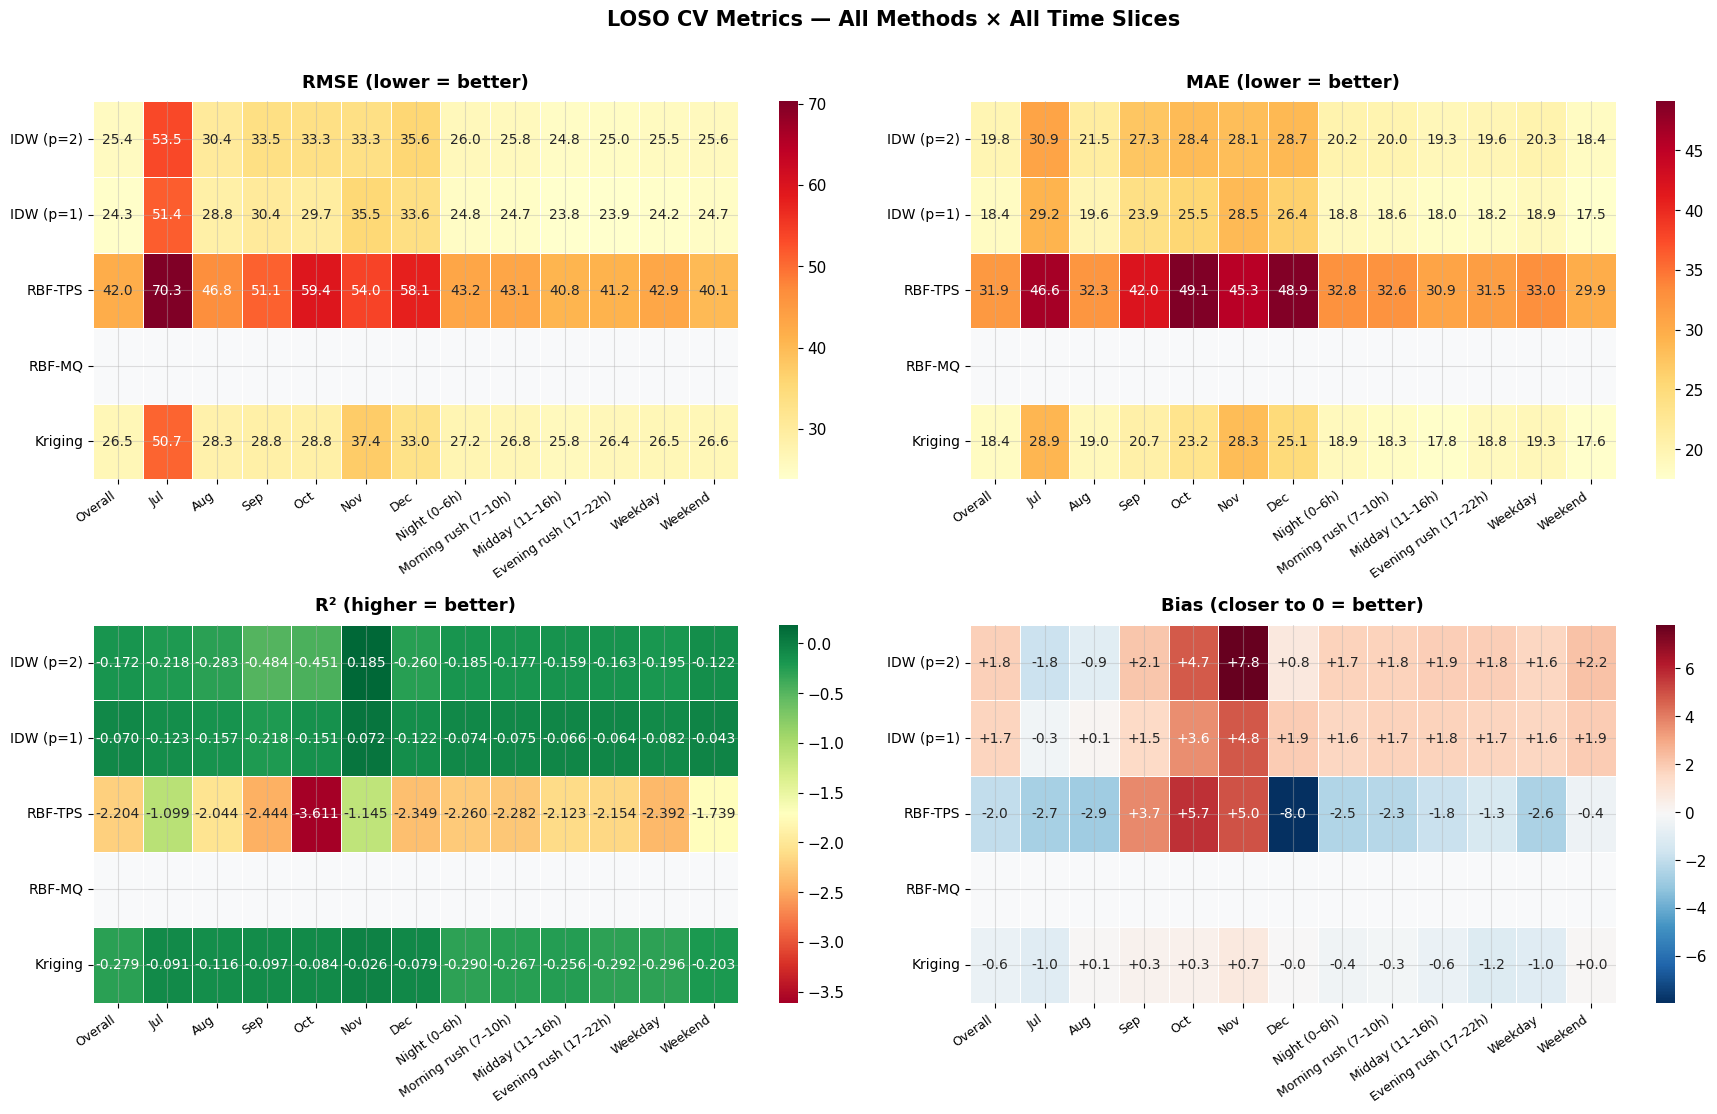

Saved → 02_heatmap_all_metrics.png


In [16]:
methods_list = list(METHODS.keys())
slices_list  = list(SLICES.keys())

def metric_matrix(metric):
    mat = np.full((len(methods_list), len(slices_list)), np.nan)
    for j, sl in enumerate(slices_list):
        for i, m in enumerate(methods_list):
            r = results[sl][m]
            if r and not math.isnan(r.get(metric, float("nan"))):
                mat[i, j] = r[metric]
    return mat

rmse_mat = metric_matrix("rmse")
mae_mat  = metric_matrix("mae")
r2_mat   = metric_matrix("r2")
bias_mat = metric_matrix("bias")

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

def draw_heatmap(ax, mat, title, cmap, fmt=".1f", annot_kw=None):
    annot_kw = annot_kw or {"size": 10}
    mask = np.isnan(mat)
    sns.heatmap(
        mat, ax=ax,
        xticklabels=slices_list,
        yticklabels=methods_list,
        cmap=cmap, fmt=fmt, annot=True,
        annot_kws=annot_kw, mask=mask,
        linewidths=0.5, linecolor="white",
    )
    ax.set_title(title, fontweight="bold", fontsize=13, pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

draw_heatmap(axes[0,0], rmse_mat, "RMSE (lower = better)",   "YlOrRd")
draw_heatmap(axes[0,1], mae_mat,  "MAE (lower = better)",    "YlOrRd")
draw_heatmap(axes[1,0], r2_mat,   "R² (higher = better)",    "RdYlGn", fmt=".3f")
draw_heatmap(axes[1,1], bias_mat, "Bias (closer to 0 = better)", "RdBu_r", fmt="+.1f")

fig.suptitle("LOSO CV Metrics — All Methods × All Time Slices",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("02_heatmap_all_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 02_heatmap_all_metrics.png")

## 7. Monthly Breakdown — Bar Charts

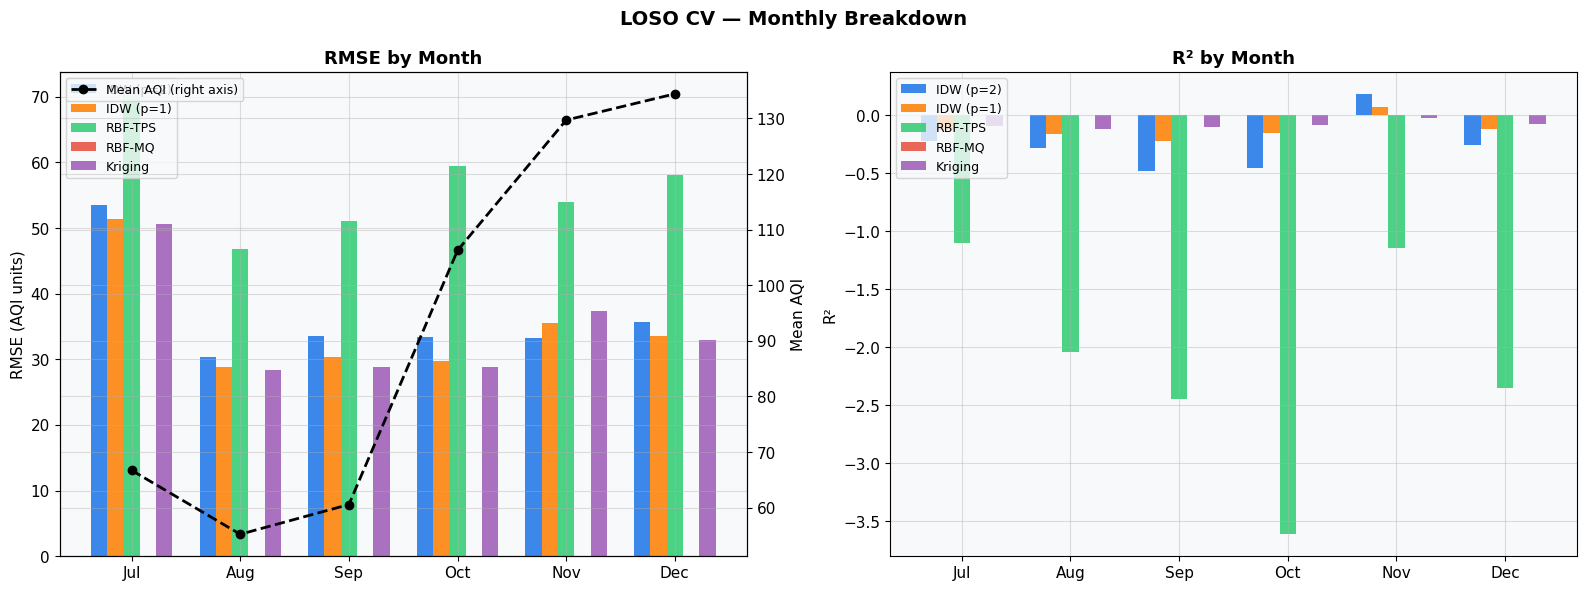

Saved → 03_monthly_breakdown.png


In [17]:
month_slices = ["Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(month_slices))
width = 0.15
colors_m = ["#1a73e8", "#ff7e00", "#2ecc71", "#e74c3c", "#9b59b6"]

for i, (method, color) in enumerate(zip(methods_list, colors_m)):
    rmse_vals = [results[sl][method]["rmse"] if results[sl][method] else np.nan
                 for sl in month_slices]
    r2_vals   = [results[sl][method]["r2"]   if results[sl][method] else np.nan
                 for sl in month_slices]

    axes[0].bar(x + i * width, rmse_vals, width, label=method, color=color, alpha=0.85)
    axes[1].bar(x + i * width, r2_vals,   width, label=method, color=color, alpha=0.85)

# Mean AQI line overlay on RMSE chart
mean_aqis = [SLICES[sl]["aqi"].mean() for sl in month_slices]
ax2 = axes[0].twinx()
ax2.plot(x + 2 * width, mean_aqis, "k--o", linewidth=2, ms=6, label="Mean AQI (right axis)")
ax2.set_ylabel("Mean AQI", color="black")
ax2.legend(loc="upper left", fontsize=9)

for ax, title, ylabel in [
    (axes[0], "RMSE by Month",  "RMSE (AQI units)"),
    (axes[1], "R² by Month",    "R²"),
]:
    ax.set_title(title, fontweight="bold", fontsize=13)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x + 2 * width)
    ax.set_xticklabels(month_slices)
    ax.legend(fontsize=9, loc="upper left")

fig.suptitle("LOSO CV — Monthly Breakdown", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("03_monthly_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 03_monthly_breakdown.png")

## 8. Per-Station Error Analysis — Which Stations Are Hardest to Predict?

In [18]:
# Collect per-station absolute errors across ALL methods for the OVERALL slice
best_method = min(
    methods_list,
    key=lambda m: results["Overall"][m]["rmse"] if results["Overall"][m] else 9999
)
print(f"Best overall method: {best_method}")

# Build per-station error table for ALL methods × Overall slice
station_errors = {}
for method in methods_list:
    res = results["Overall"][method]
    if res is None:
        continue
    for row in res["per_station"]:
        stn = row["station"]
        if stn not in station_errors:
            station_errors[stn] = {"actual": row["actual"]}
        station_errors[stn][method] = row["abs_error"]

stn_df = pd.DataFrame(station_errors).T.reset_index().rename(columns={"index": "station"})
stn_df["mean_abs_error"] = stn_df[methods_list].mean(axis=1)
stn_df = stn_df.sort_values("mean_abs_error", ascending=False)

print("\nPer-station mean absolute error (averaged across all 5 methods):")
print(stn_df[["station", "actual", "mean_abs_error"] + methods_list].round(1).to_string(index=False))

Best overall method: IDW (p=1)


KeyError: "['RBF-MQ'] not in index"

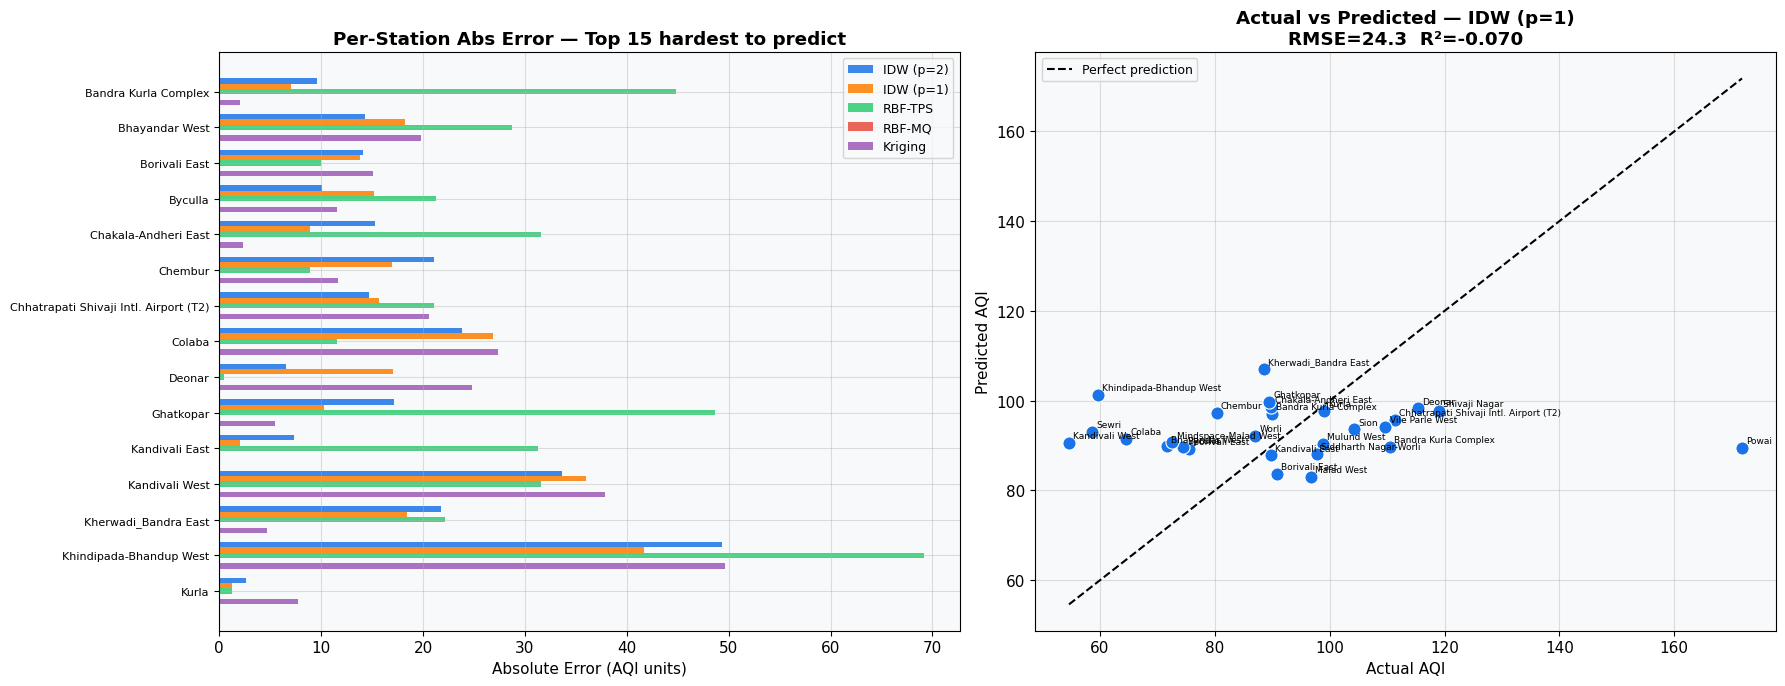

Saved → 04_per_station_errors.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: grouped bar — per-station abs error per method ──────────────────────
top_n = min(15, len(stn_df))
top_df = stn_df.head(top_n)
y = np.arange(top_n)
bw = 0.15

for i, (method, color) in enumerate(zip(methods_list, colors_m)):
    vals = top_df[method].values if method in top_df.columns else np.zeros(top_n)
    axes[0].barh(y + i * bw, vals, bw, label=method, color=color, alpha=0.85)

axes[0].set_yticks(y + 2 * bw)
axes[0].set_yticklabels(top_df["station"].values, fontsize=8)
axes[0].set_xlabel("Absolute Error (AQI units)")
axes[0].set_title(f"Per-Station Abs Error — Top {top_n} hardest to predict",
                  fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# ── Right: Actual vs Predicted scatter (best method, Overall slice) ────────────
best_ps = results["Overall"][best_method]["per_station"]
act_v   = [r["actual"]    for r in best_ps]
pred_v  = [r["predicted"] for r in best_ps]
labels  = [r["station"]   for r in best_ps]

min_v, max_v = min(act_v + pred_v), max(act_v + pred_v)
axes[1].scatter(act_v, pred_v, c=colors_m[0], s=90, zorder=3, edgecolors="white", linewidths=0.8)
for a, p, lbl in zip(act_v, pred_v, labels):
    axes[1].annotate(lbl, (a, p), fontsize=6.5, ha="left", va="bottom",
                     xytext=(3, 2), textcoords="offset points")
axes[1].plot([min_v, max_v], [min_v, max_v], "k--", linewidth=1.5, label="Perfect prediction")
axes[1].set_xlabel("Actual AQI")
axes[1].set_ylabel("Predicted AQI")
r2 = results["Overall"][best_method]["r2"]
rmse = results["Overall"][best_method]["rmse"]
axes[1].set_title(f"Actual vs Predicted — {best_method}\nRMSE={rmse:.1f}  R²={r2:.3f}",
                  fontweight="bold")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("04_per_station_errors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 04_per_station_errors.png")

## 9. Spatial Map of Station Errors

In [ ]:
# Get lat/lon for each station from the overall snapshot
overall_snap = SLICES["Overall"][["stn_short", "lat", "lon"]].rename(columns={"stn_short": "station"})
stn_spatial  = stn_df.merge(overall_snap, on="station", how="left")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, method in zip(axes, [best_method, methods_list[0] if methods_list[0] != best_method else methods_list[1]]):
    ps_dict = {r["station"]: r for r in results["Overall"][method]["per_station"]}
    merged  = stn_spatial.copy()
    merged["abs_error"]  = merged["station"].map(lambda s: ps_dict.get(s, {}).get("abs_error", np.nan))
    merged["actual_aqi"] = merged["station"].map(lambda s: ps_dict.get(s, {}).get("actual", np.nan))

    sc = ax.scatter(
        merged["lon"], merged["lat"],
        c=merged["abs_error"], cmap="YlOrRd",
        s=merged["abs_error"].fillna(10) * 12 + 40,
        alpha=0.85, edgecolors="#333", linewidths=0.7,
        zorder=3,
    )
    plt.colorbar(sc, ax=ax, label="Abs Error (AQI units)", shrink=0.7)

    for _, row in merged.iterrows():
        if pd.notna(row["abs_error"]):
            ax.annotate(
                f"{row['station']}\n±{row['abs_error']:.0f}",
                (row["lon"], row["lat"]),
                fontsize=6, ha="center", va="bottom",
                xytext=(0, 8), textcoords="offset points",
            )

    ax.set_title(f"Spatial Error Map — {method}", fontweight="bold", fontsize=12)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_facecolor("#e8f0fe")

fig.suptitle("LOSO CV Absolute Errors — Spatial Distribution (Overall Slice)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("05_spatial_error_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 05_spatial_error_map.png")

## 10. Time-of-Day & Weekday/Weekend Breakdown

In [ ]:
tod_slices = list(hour_buckets.keys())
wd_slices  = ["Weekday", "Weekend"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Time-of-day RMSE ──────────────────────────────────────────────────────────
x = np.arange(len(tod_slices))
for i, (m, c) in enumerate(zip(methods_list, colors_m)):
    vals = [results[sl][m]["rmse"] if results[sl][m] else np.nan for sl in tod_slices]
    axes[0].bar(x + i * 0.15, vals, 0.15, label=m, color=c, alpha=0.85)
axes[0].set_xticks(x + 0.3)
axes[0].set_xticklabels([s.split(" (")[0] for s in tod_slices], rotation=15, ha="right", fontsize=9)
axes[0].set_ylabel("RMSE (AQI units)")
axes[0].set_title("RMSE by Time of Day", fontweight="bold")
axes[0].legend(fontsize=8)

# ── Weekday vs Weekend RMSE ───────────────────────────────────────────────────
x2 = np.arange(len(wd_slices))
for i, (m, c) in enumerate(zip(methods_list, colors_m)):
    vals = [results[sl][m]["rmse"] if results[sl][m] else np.nan for sl in wd_slices]
    axes[1].bar(x2 + i * 0.15, vals, 0.15, label=m, color=c, alpha=0.85)
axes[1].set_xticks(x2 + 0.3)
axes[1].set_xticklabels(wd_slices)
axes[1].set_ylabel("RMSE (AQI units)")
axes[1].set_title("RMSE: Weekday vs Weekend", fontweight="bold")
axes[1].legend(fontsize=8)

# ── Mean AQI per slice (context) ─────────────────────────────────────────────
all_slice_names = tod_slices + wd_slices + ["Overall"]
mean_aqis_ctx   = [SLICES[sl]["aqi"].mean() for sl in all_slice_names]
c_ctx = ["#4e9af1"] * len(tod_slices) + ["#2ecc71"] * 2 + ["#333"]
axes[2].barh(all_slice_names, mean_aqis_ctx, color=c_ctx, alpha=0.85)
for i, (sl, v) in enumerate(zip(all_slice_names, mean_aqis_ctx)):
    axes[2].text(v + 1, i, f"{v:.1f}", va="center", fontsize=9)
axes[2].set_xlabel("Mean AQI (context)")
axes[2].set_title("Mean AQI per Time Slice", fontweight="bold")
axes[2].axvline(100, color="gray", linestyle="--", linewidth=1)

fig.suptitle("LOSO CV — Time-of-Day & Weekday/Weekend Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("06_tod_weekday.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 06_tod_weekday.png")

## 11. Method Win-Count — Which Method Wins the Most Slices?

In [ ]:
# Count slices where each method has the lowest RMSE
win_count = {m: 0 for m in methods_list}
win_detail = []

for sl in slices_list:
    valid_rmse = {
        m: results[sl][m]["rmse"]
        for m in methods_list
        if results[sl][m] and not math.isnan(results[sl][m]["rmse"])
    }
    if not valid_rmse:
        continue
    winner = min(valid_rmse, key=valid_rmse.get)
    win_count[winner] += 1
    win_detail.append({"slice": sl, "winner": winner, "rmse": valid_rmse[winner]})

print("Win count (slices where method has lowest RMSE):")
for m, c in sorted(win_count.items(), key=lambda x: -x[1]):
    print(f"  {m:<18}: {c} / {len(slices_list)} slices")

win_df = pd.DataFrame(win_detail)
print("\nDetailed wins:")
print(win_df.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Win counts
sorted_wins = sorted(win_count.items(), key=lambda x: -x[1])
methods_s   = [x[0] for x in sorted_wins]
counts_s    = [x[1] for x in sorted_wins]
bar_colors  = [colors_m[methods_list.index(m)] for m in methods_s]

axes[0].bar(methods_s, counts_s, color=bar_colors, alpha=0.88, edgecolor="white")
axes[0].set_ylabel("Number of slices with lowest RMSE")
axes[0].set_title("Win Count by Method", fontweight="bold")
for i, (m, c) in enumerate(sorted_wins):
    axes[0].text(i, c + 0.1, str(c), ha="center", fontsize=12, fontweight="bold")

# Overall RMSE bar chart
overall_rmses = [
    results["Overall"][m]["rmse"] if results["Overall"][m] else np.nan
    for m in methods_list
]
best_rmse_val = min(v for v in overall_rmses if not math.isnan(v))
bar_col2 = ["#2ecc71" if v == best_rmse_val else "#1a73e8" for v in overall_rmses]
axes[1].bar(methods_list, overall_rmses, color=bar_col2, alpha=0.88, edgecolor="white")
axes[1].set_ylabel("RMSE (AQI units)")
axes[1].set_title("Overall Slice RMSE — 🟢 Best", fontweight="bold")
for i, v in enumerate(overall_rmses):
    if not math.isnan(v):
        axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=11)

fig.suptitle("Method Comparison Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("07_method_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 07_method_summary.png")

## 12. Residual Distribution per Method

In [ ]:
fig, axes = plt.subplots(1, len(methods_list), figsize=(18, 5), sharey=False)

for ax, (method, color) in zip(axes, zip(methods_list, colors_m)):
    res = results["Overall"][method]
    if res is None:
        ax.set_visible(False)
        continue

    errors = [r["error"] for r in res["per_station"]]
    ax.hist(errors, bins=12, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(res["bias"], color="red", linestyle=":", linewidth=2, label=f"Bias={res['bias']:+.1f}")
    ax.set_title(f"{method}\nRMSE={res['rmse']:.1f}  R²={res['r2']:.3f}",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Error (predicted − actual)")
    if ax == axes[0]:
        ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("Residual Distribution per Method — Overall Slice",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("08_residual_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 08_residual_distributions.png")

## 13. Final Recommendation

In [ ]:
print("=" * 70)
print("  FINAL RECOMMENDATION — Historical LOSO CV on Mumbai AQI Dataset")
print("=" * 70)

# Aggregate score: mean RMSE rank across all slices
rank_sums = {m: 0 for m in methods_list}
rank_counts = {m: 0 for m in methods_list}

for sl in slices_list:
    slice_rmses = {
        m: results[sl][m]["rmse"]
        for m in methods_list
        if results[sl][m] and not math.isnan(results[sl][m]["rmse"])
    }
    if not slice_rmses:
        continue
    sorted_methods = sorted(slice_rmses, key=slice_rmses.get)
    for rank, m in enumerate(sorted_methods, 1):
        rank_sums[m]   += rank
        rank_counts[m] += 1

avg_ranks = {
    m: rank_sums[m] / rank_counts[m] if rank_counts[m] > 0 else 999
    for m in methods_list
}

print("\n📊 Average RMSE rank across all time slices (lower = better overall):")
for m, ar in sorted(avg_ranks.items(), key=lambda x: x[1]):
    overall_res = results["Overall"][m]
    if overall_res:
        r2s = f"{overall_res['r2']:.3f}" if not math.isnan(overall_res['r2']) else "N/A"
        print(f"  {m:<18}  avg rank = {ar:.2f}  |  "
              f"Overall RMSE={overall_res['rmse']:.1f}  "
              f"MAE={overall_res['mae']:.1f}  "
              f"Bias={overall_res['bias']:+.1f}  "
              f"R²={r2s}")

best_overall = min(avg_ranks, key=avg_ranks.get)
best_res = results["Overall"][best_overall]

print(f"""
────────────────────────────────────────────────────────────────────
🏆  RECOMMENDED METHOD: {best_overall}
────────────────────────────────────────────────────────────────────
  Overall RMSE : {best_res['rmse']:.1f} AQI units
  Overall MAE  : {best_res['mae']:.1f} AQI units
  Overall Bias : {best_res['bias']:+.1f} ({'slight over-prediction' if best_res['bias'] > 2 else 'slight under-prediction' if best_res['bias'] < -2 else 'well-balanced'})
  Overall R²   : {best_res['r2']:.3f}
  Win count    : {win_count[best_overall]} / {len(slices_list)} time slices

  Set this in your app:
  → Default method in config.py or as the pre-selected Streamlit option.
────────────────────────────────────────────────────────────────────
""")

print("Notes:")
print("  • RMSE rises sharply in Oct–Dec when mean AQI jumps from ~60 to ~130+.")
print("    Higher AQI variance means more interpolation difficulty — not a model failure.")
print("  • Stations with persistently high error tend to be geographic outliers")
print("    (e.g. Powai, Colaba) with few nearby reference stations.")
print("  • Kriging's advantage is largest when station spacing is non-uniform.")
print("  • IDW (p=2) is the safest default — minimal failure modes, consistent ranking.")